# 1. Problem Definition
- The goal of this project is to develop a machine learning model capable of predicting whether a breast tumor is malignant based on features extracted from medical data.

- This is a supervised binary classification problem, where the target variable indicates the diagnosis: Malignant (1) or Benign (0)

# 2. Import & Data Overview

In [2]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [3]:
# Import data

df_original = pd.read_csv('data.csv')
print(df_original.columns)
print(df_original)
print(display(df_original))
print(df_original.info())
print(df_original.describe())

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')
           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301 

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


None
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non

## Data Overview Conclusions: 
1. We might want to drop the 'Unnamed: 32'and 'ID' columns;
2. 569 samples for 33 features;
3. No missing values;
4. Data types are correctely assigned.

# EDA

In [4]:
# Drop useless columns

df = df_original.drop(columns=['id', 'Unnamed: 32'])
print(display(df))

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


None


diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


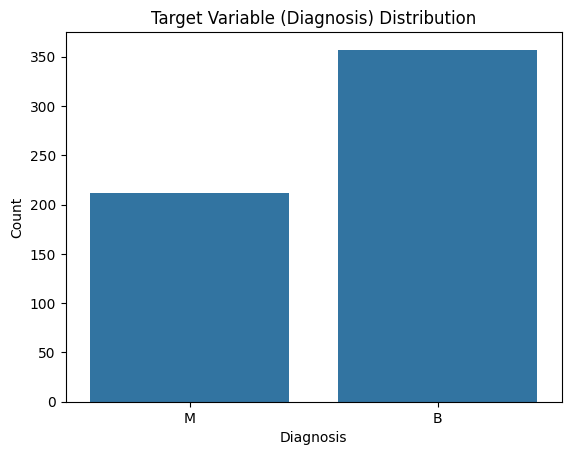

In [5]:
# Understand target variable

print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True))

# Visualize target variable distribution
sns.countplot(x='diagnosis', data=df)
plt.title('Target Variable (Diagnosis) Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()



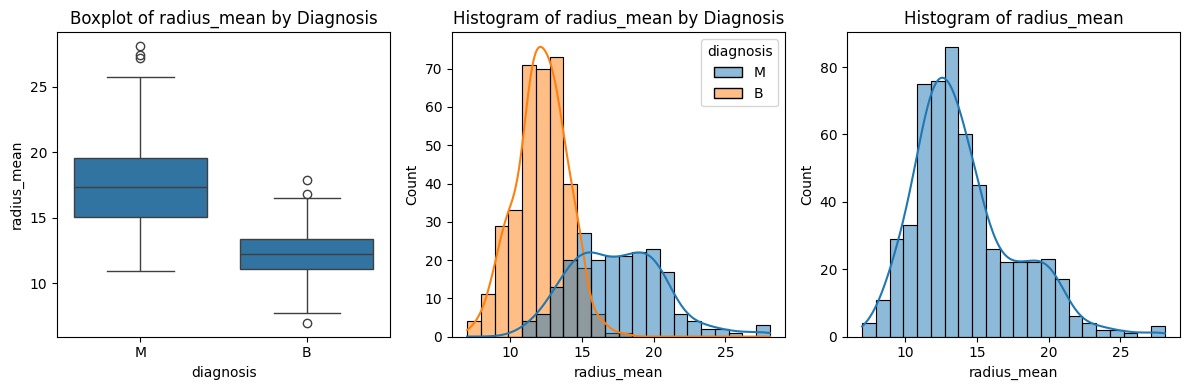

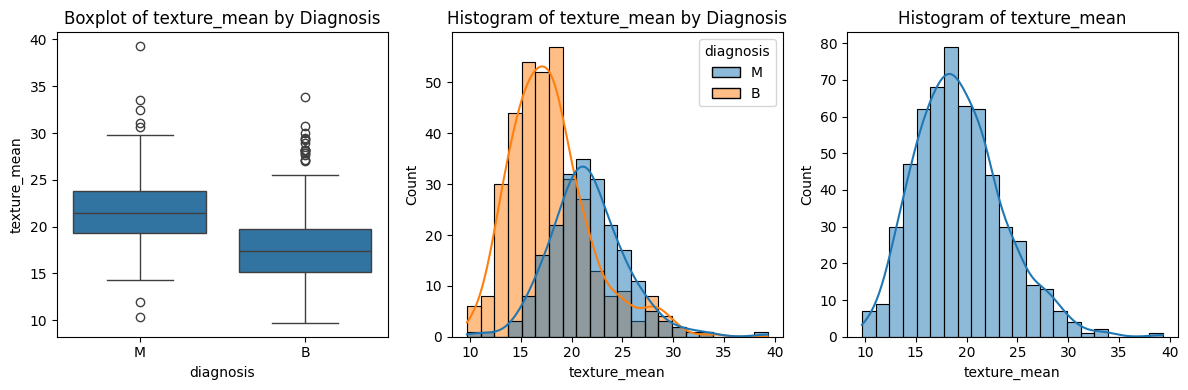

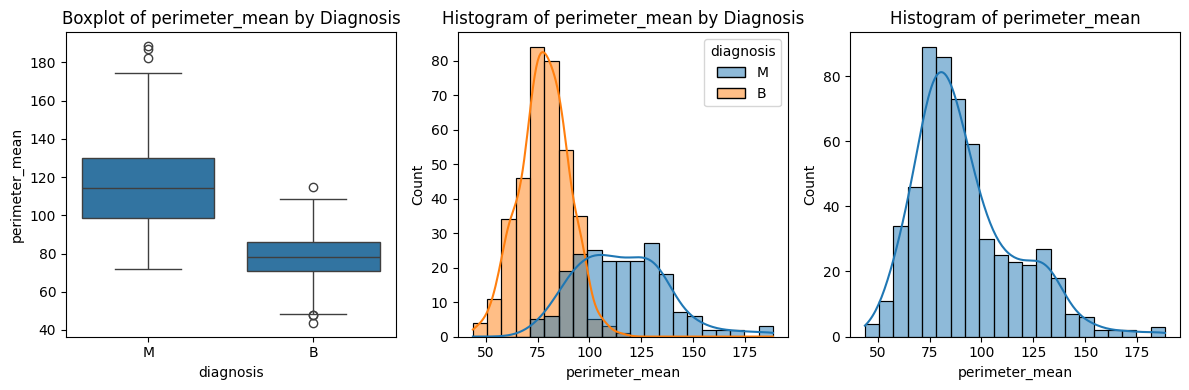

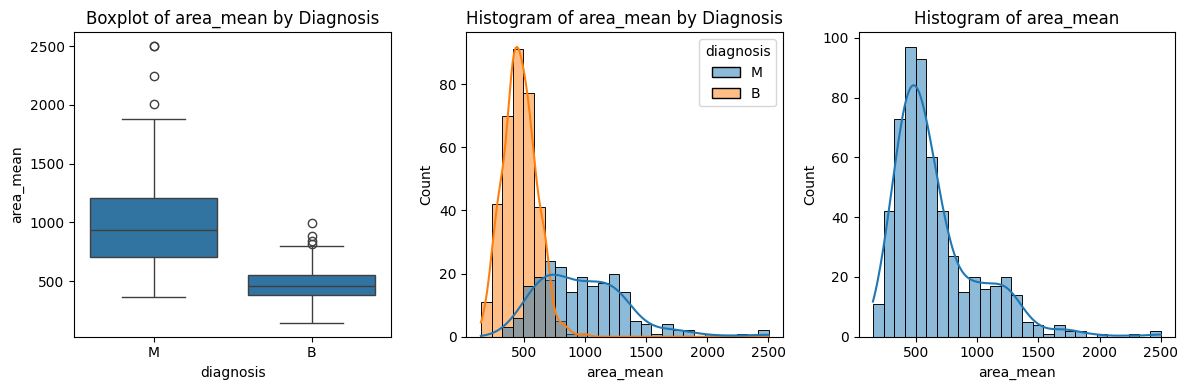

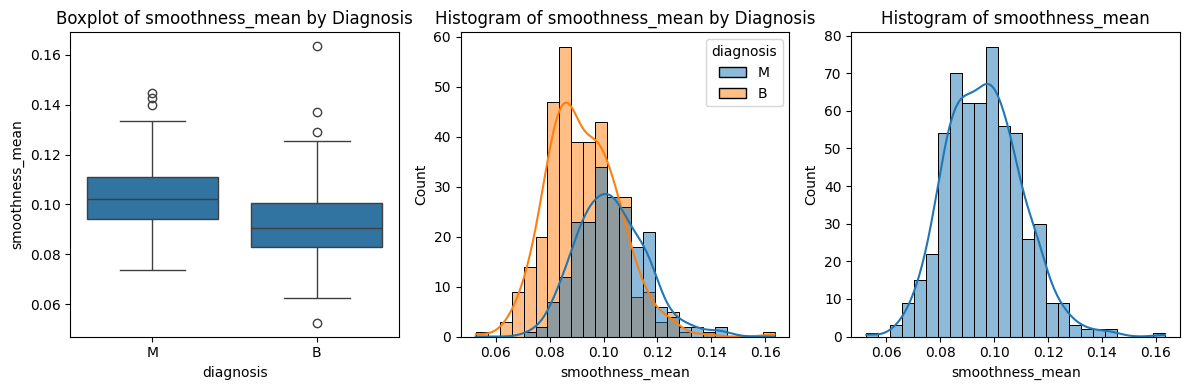

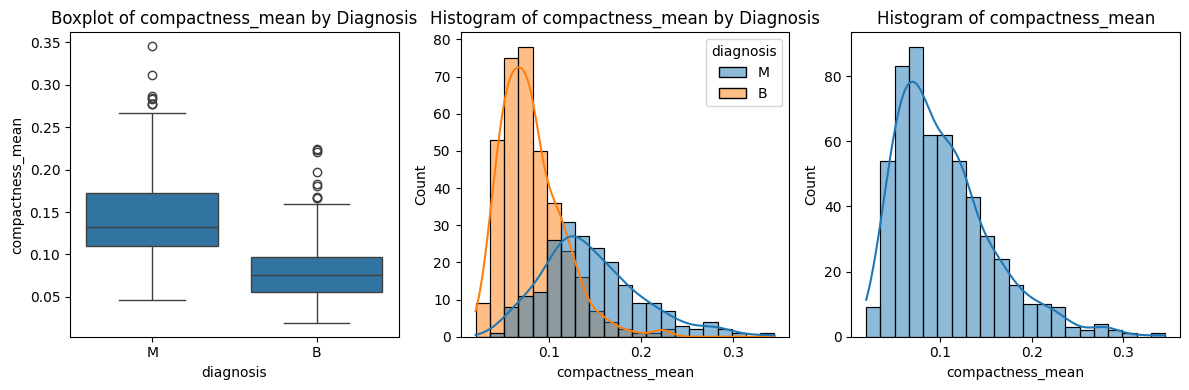

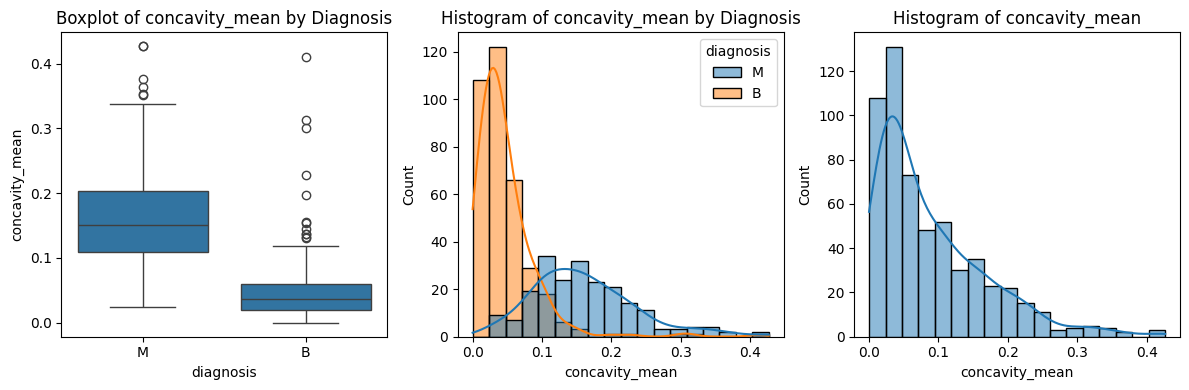

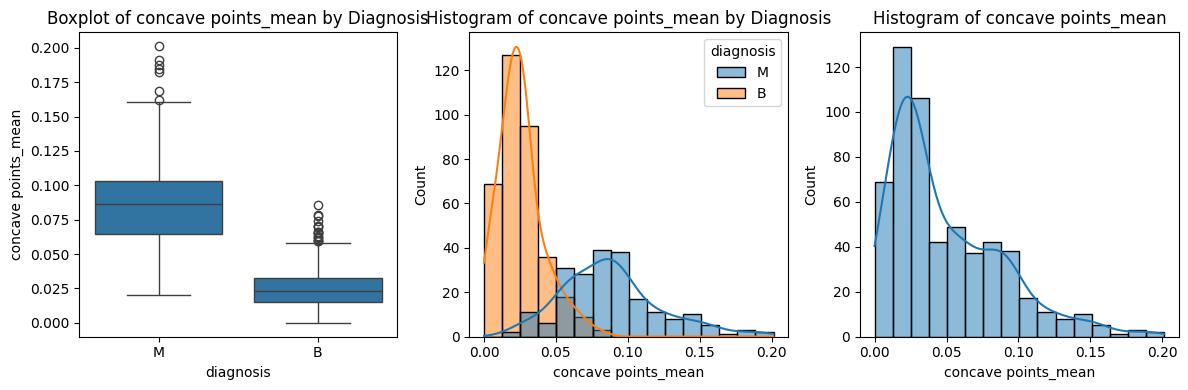

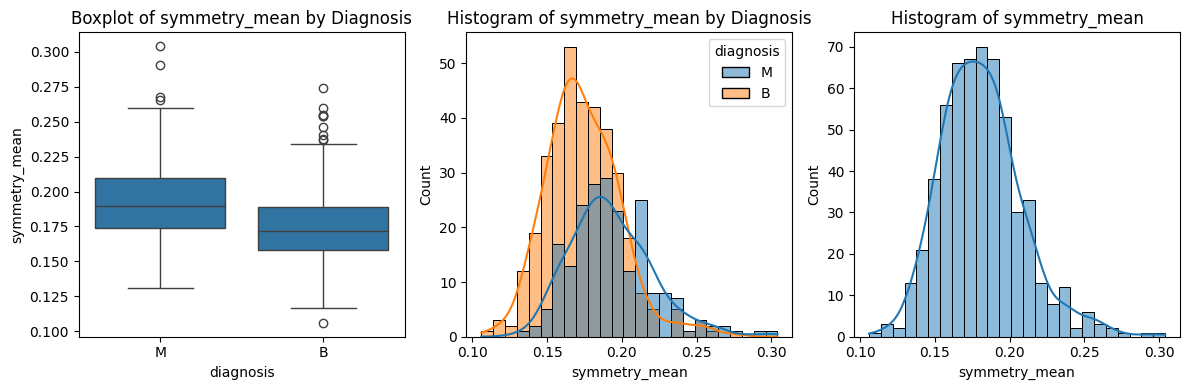

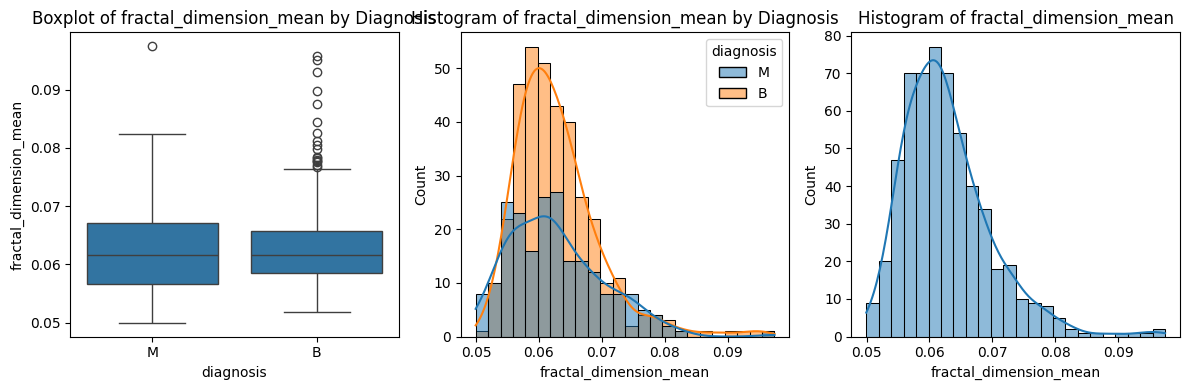

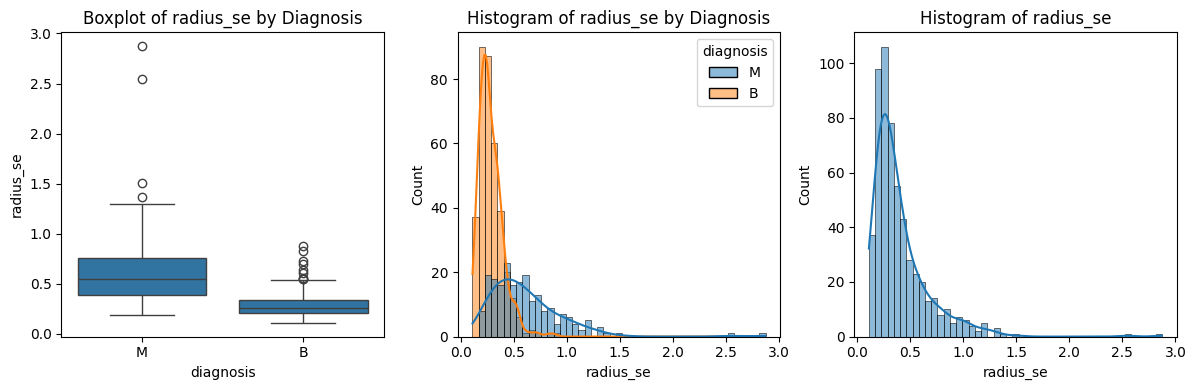

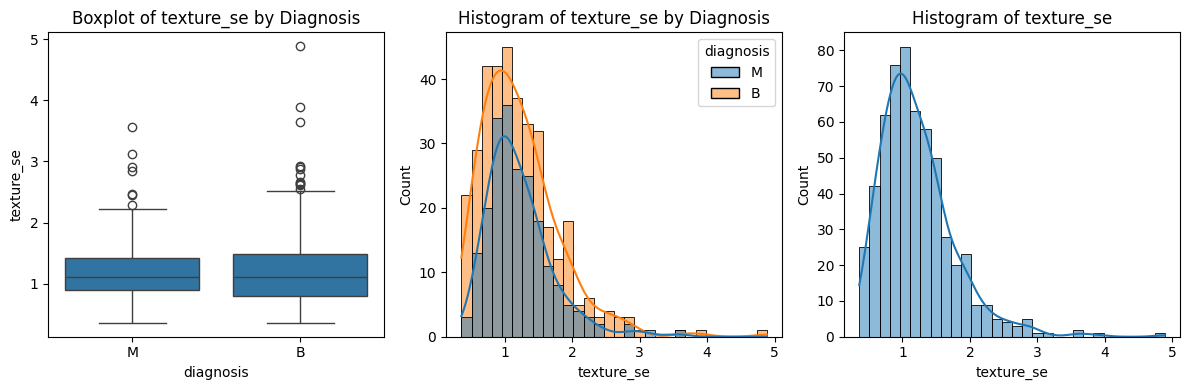

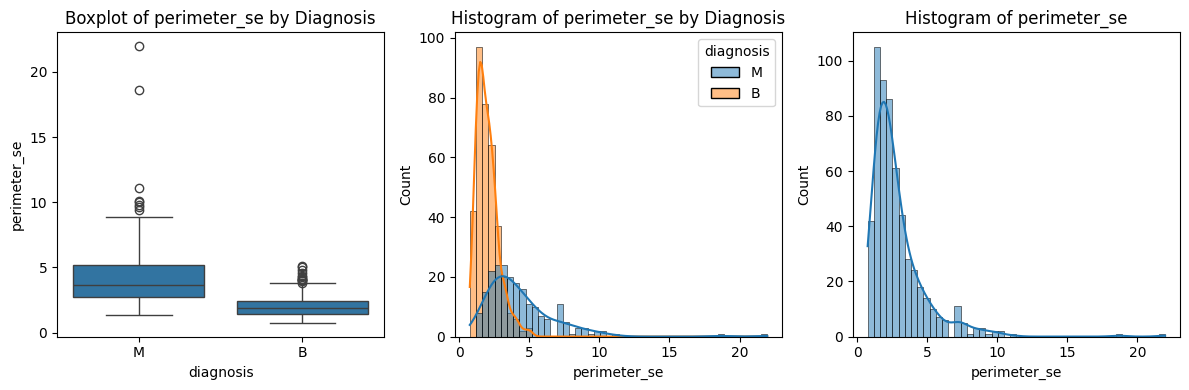

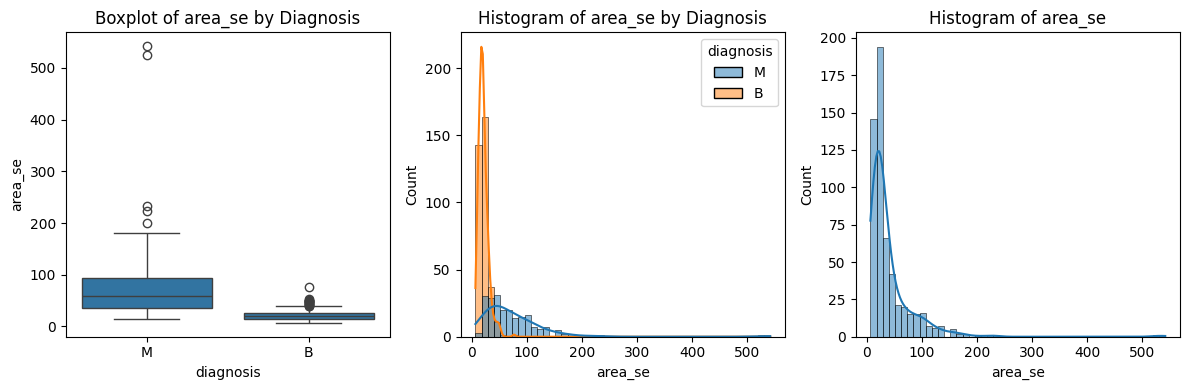

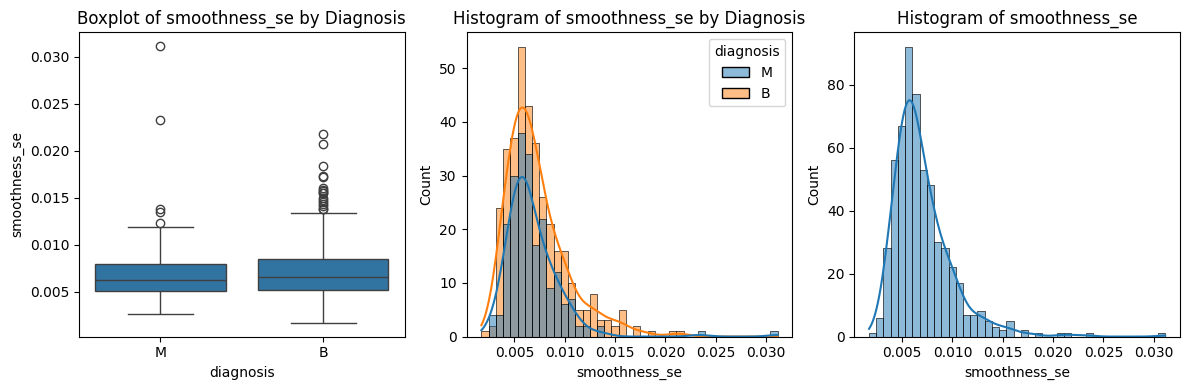

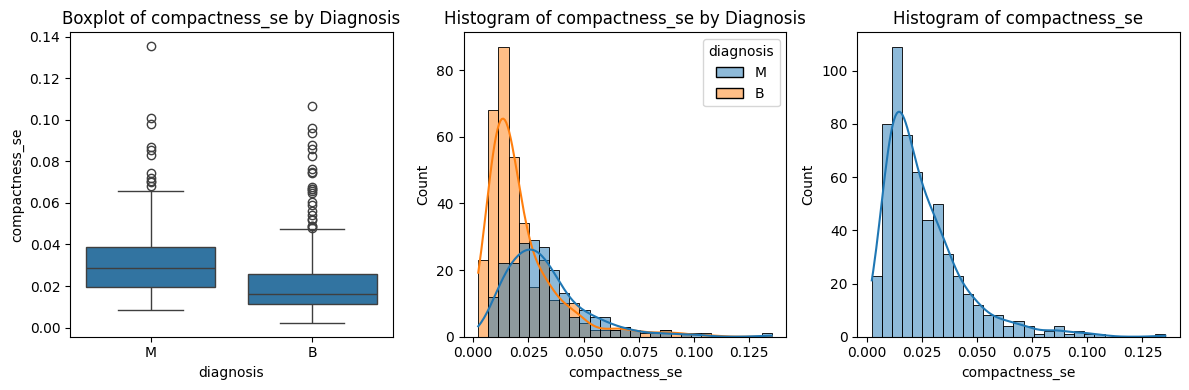

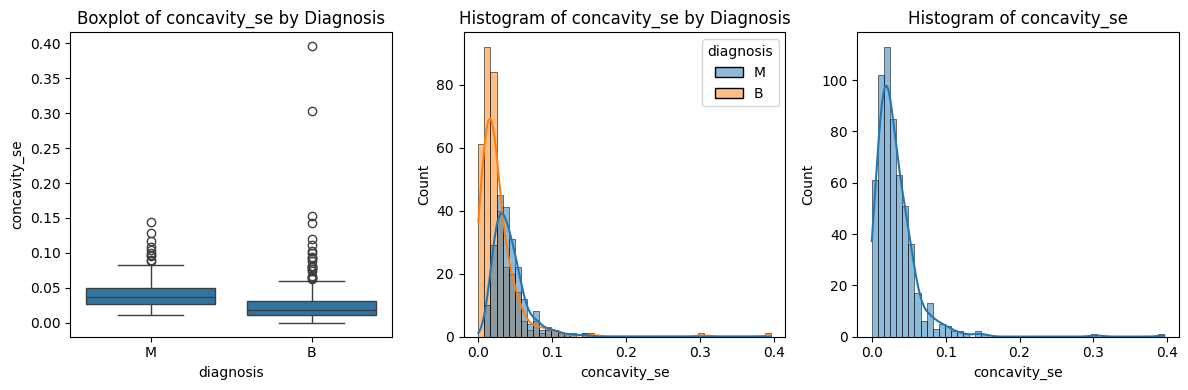

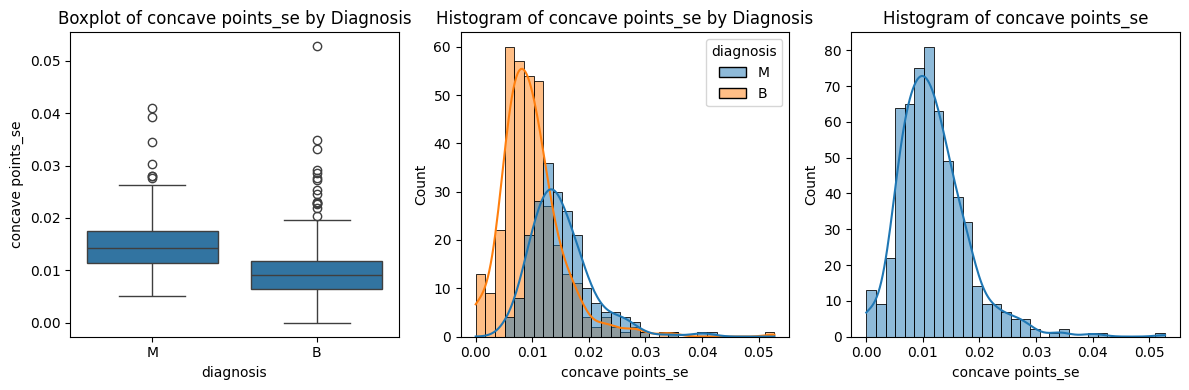

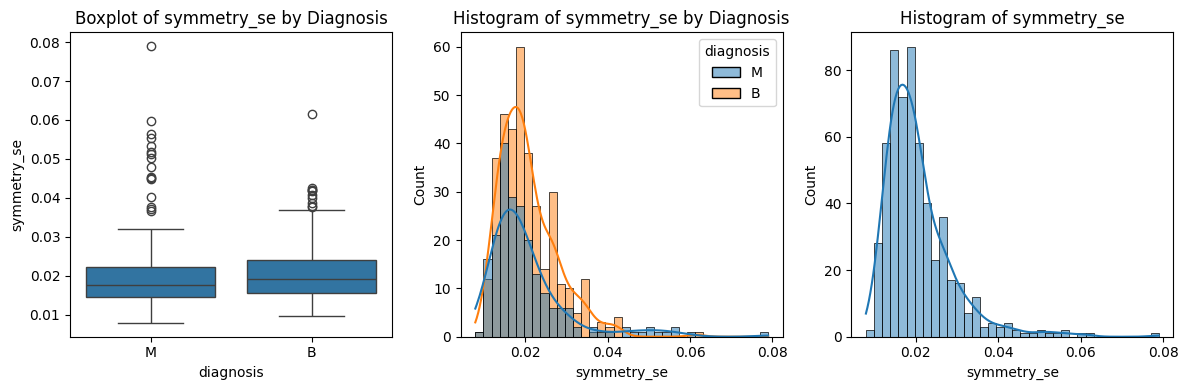

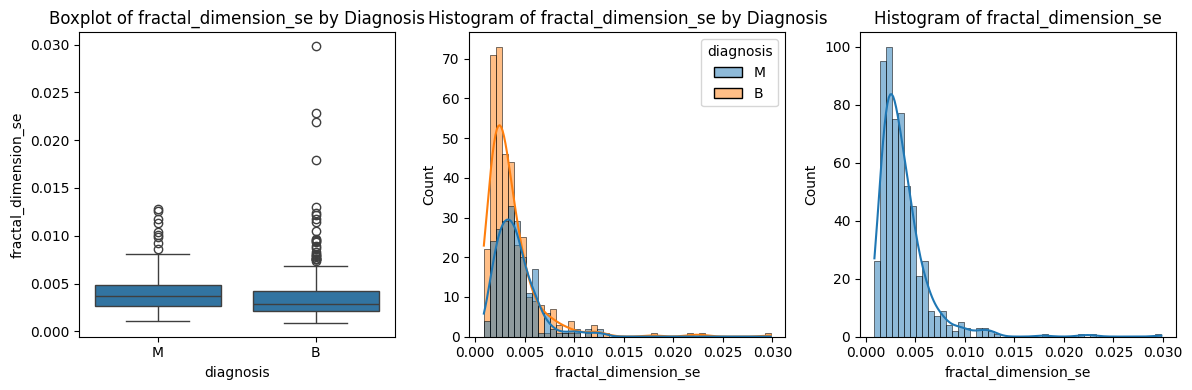

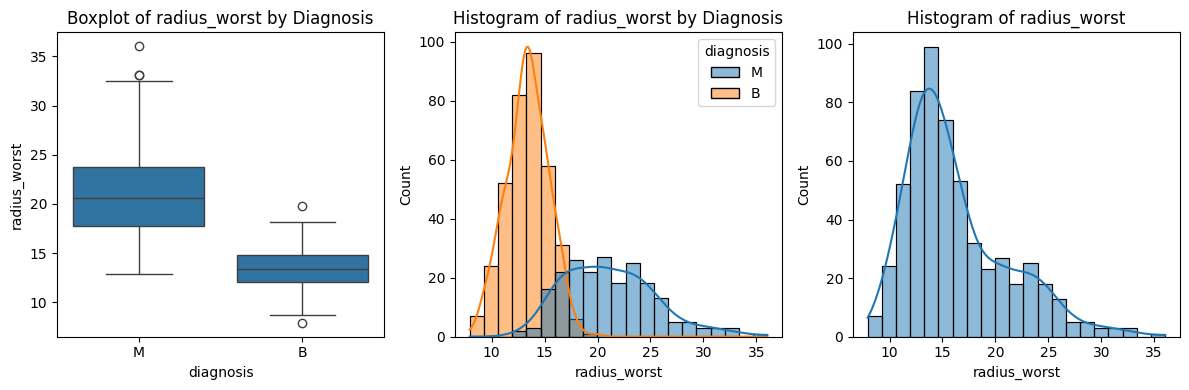

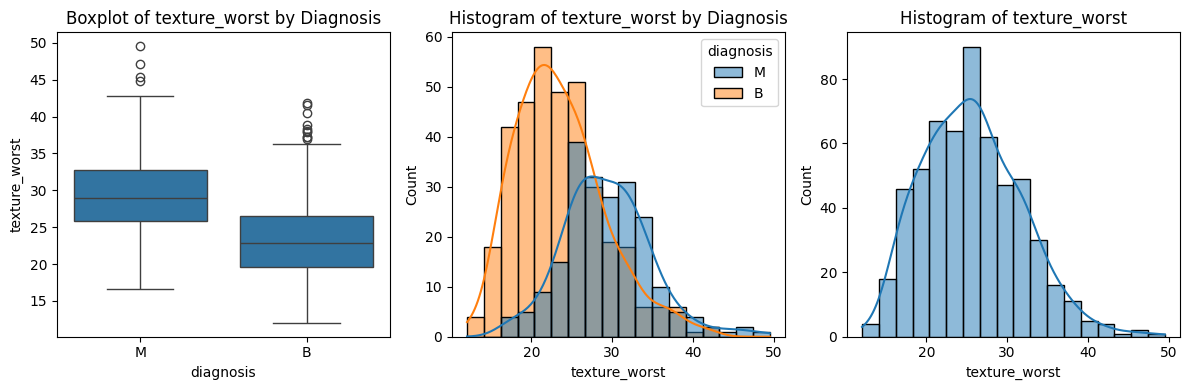

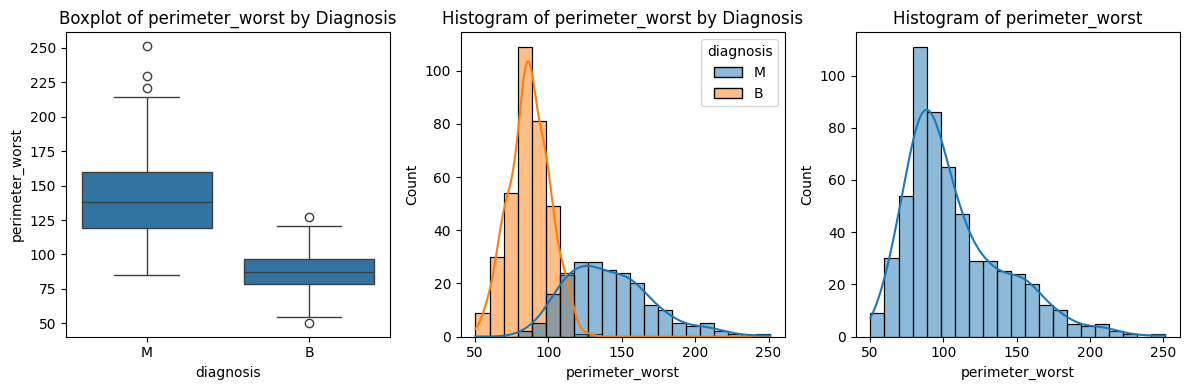

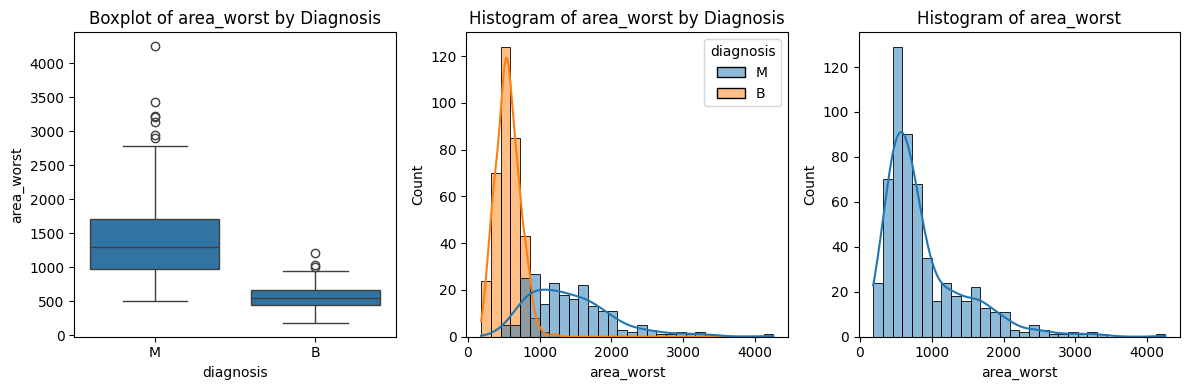

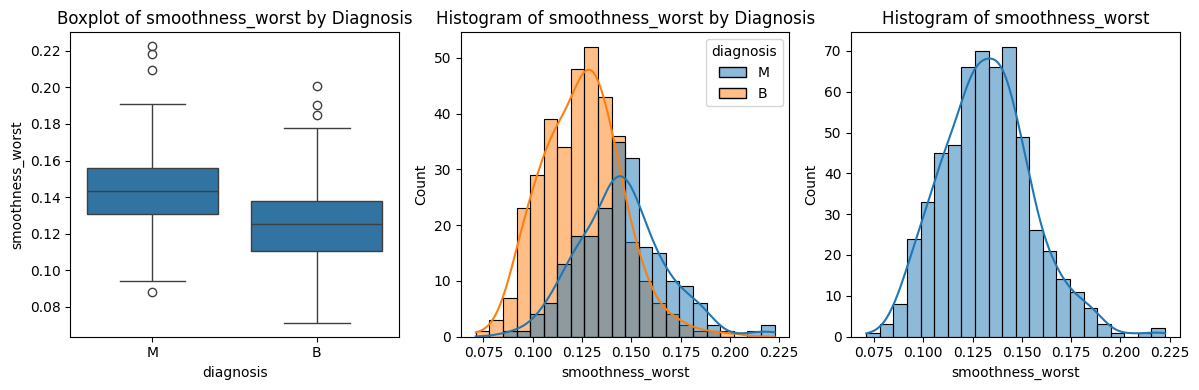

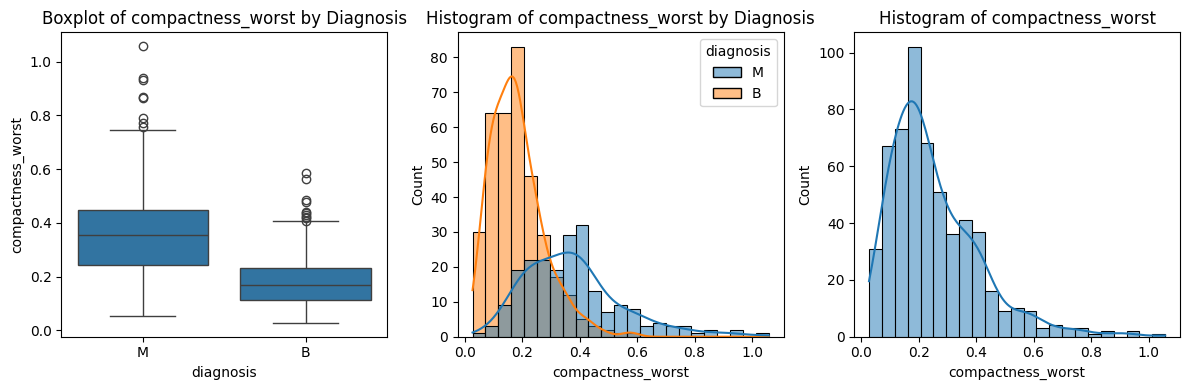

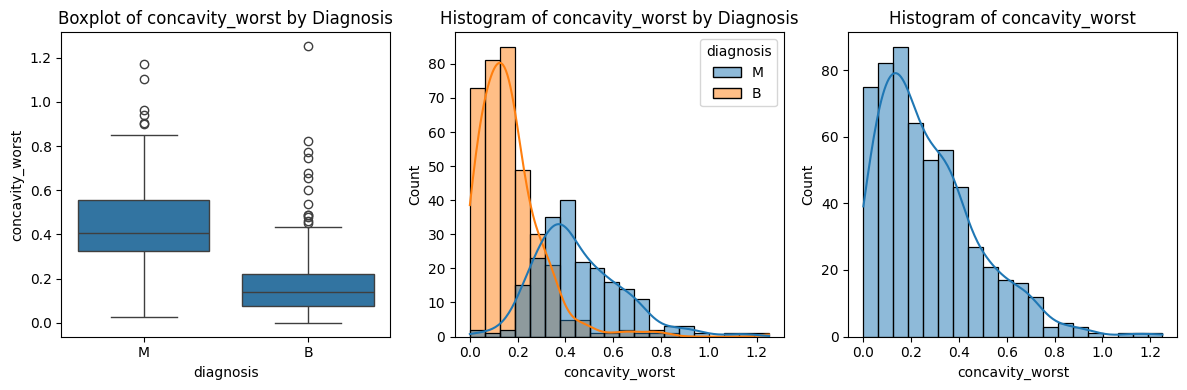

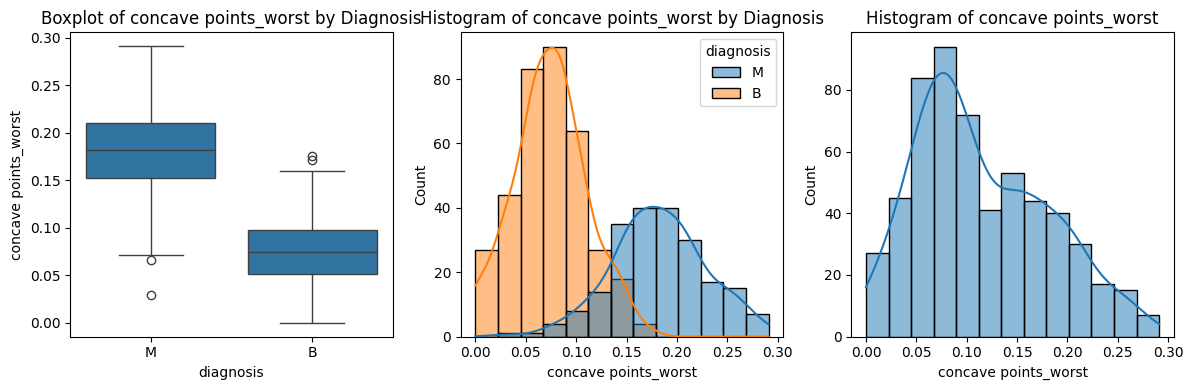

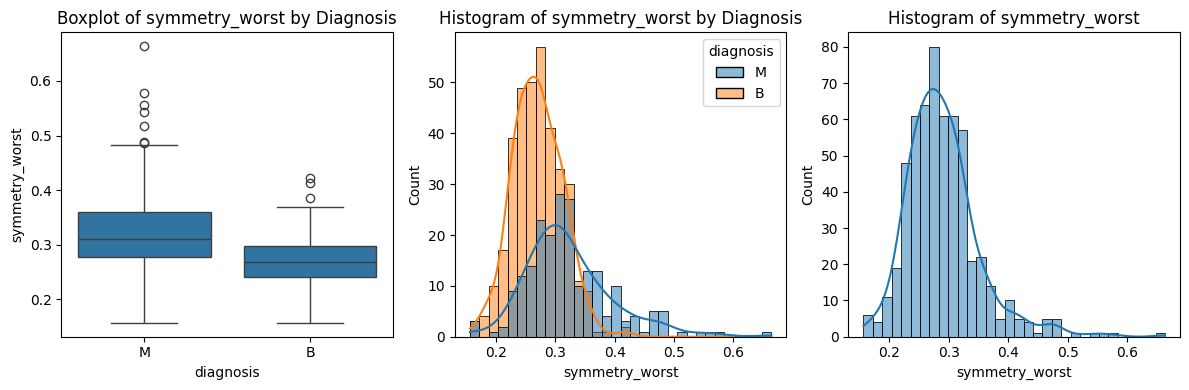

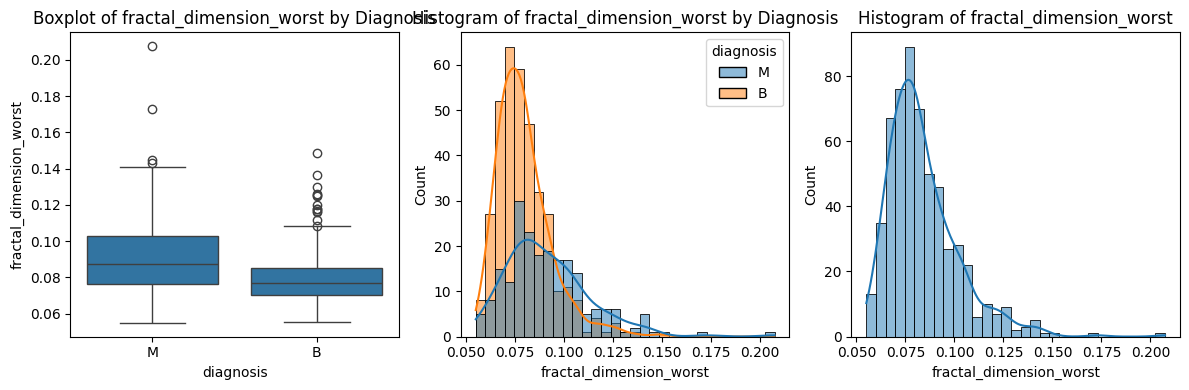

In [6]:
# Univariate analysis of features - Check for outliers, distribution, scale, etc.

    # Select numeric features (excluding the target variable)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()   

for feature in numeric_features:
    plt.figure(figsize=(12, 4))
    
    # Boxplot to check for outliers
    plt.subplot(1, 3, 1)
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by Diagnosis')
    
    # Histogram to check distribution
    plt.subplot(1, 3, 2)
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True)
    plt.title(f'Histogram of {feature} by Diagnosis')
    
    # Density plot to check distribution
    plt.subplot(1, 3, 3)
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f'Histogram of {feature}')

    plt.tight_layout()
    plt.show()

## Univariate Analysis Conclusions:

- The target variable is slightly imbalanced, with more benign than malignant cases.
- Across most features, malignant cases tend to exhibit higher values.
- Distributions for malignant cases are generally more spread out, indicating greater variability (lower kurtosis).
- Outliers appear to be legitimate observations and will be retained to preserve potentially meaningful clinical information.
- Most features show right-skewed distributions, which may justify transformations for linear models, although tree-based models could be used to avoid this step.
- Looking at the different feature ranges in min and max values, scaling will be important for certain models.

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316


None


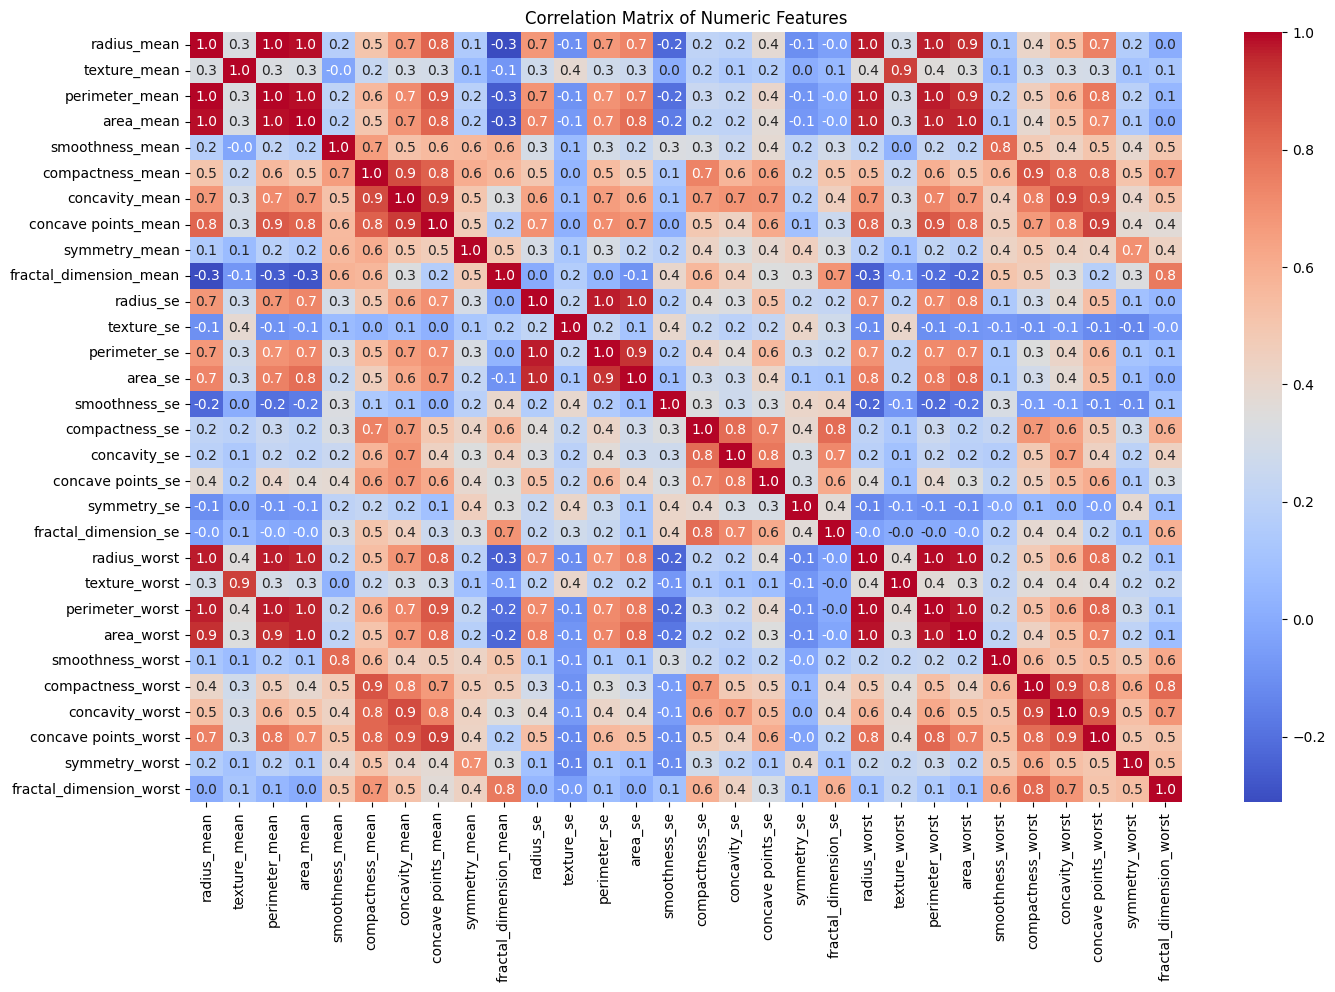

In [7]:
# Multivariate analysis - Check for correlations between features and the target variable, as well as between features themselves.

# Correlation matrix
correlation_matrix = df[numeric_features].corr()
print(display(correlation_matrix.head(5)))

# Heatmap of correlation matrix
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

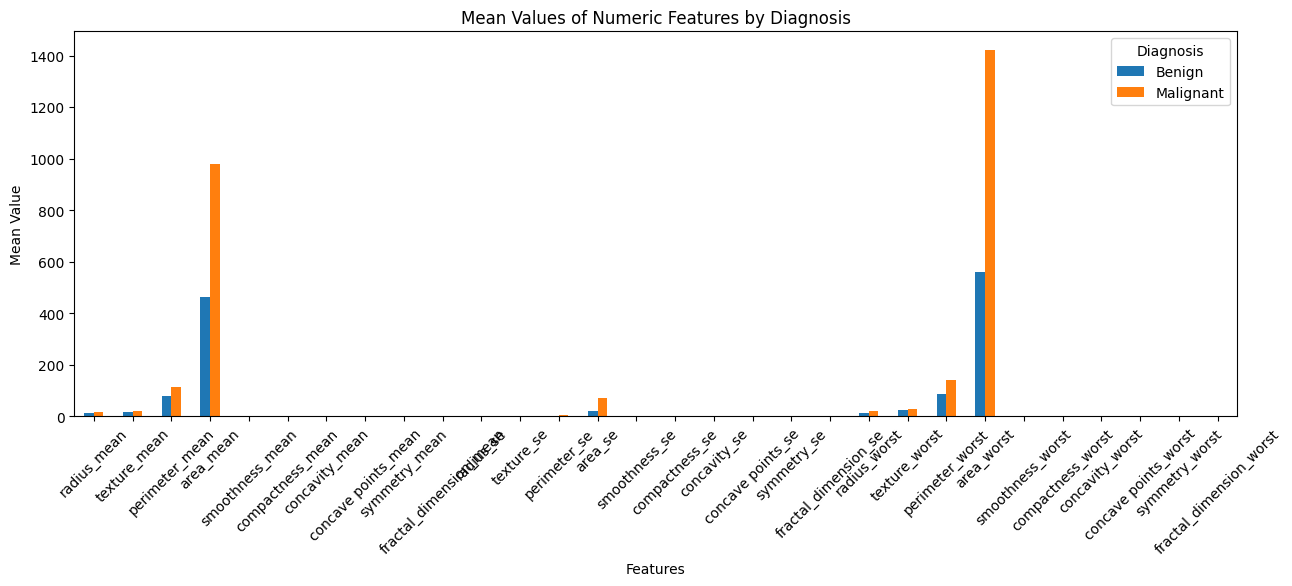

In [8]:
# Verify which features have the highest mean values for each diagnosis category

df.groupby('diagnosis').mean()[numeric_features].T.plot(kind='bar', figsize=(15, 5))
plt.title('Mean Values of Numeric Features by Diagnosis') 
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(title='Diagnosis', labels=['Benign', 'Malignant'])
plt.show()

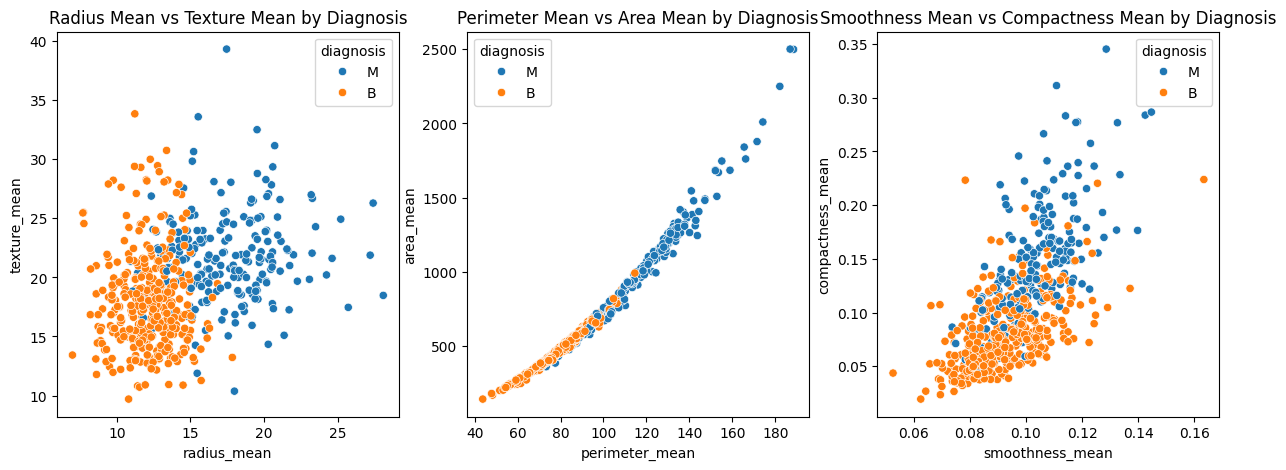

In [9]:
# Some further relations between variables and diagnosis

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df_original)
plt.title('Radius Mean vs Texture Mean by Diagnosis')

plt.subplot(1, 3, 2)
sns.scatterplot(x='perimeter_mean', y='area_mean', hue='diagnosis', data=df_original)
plt.title('Perimeter Mean vs Area Mean by Diagnosis')

plt.subplot(1, 3, 3)
sns.scatterplot(x='smoothness_mean', y='compactness_mean', hue='diagnosis', data=df_original)
plt.title('Smoothness Mean vs Compactness Mean by Diagnosis')

plt.show()


## Correlation Analysis Conclusions:

- The features related to texture and perimeter have the potential to have the most power, has their values shift greatly according to the diagnosis.

- The correlation matrix reveals strong relationships among several features, particularly those related to tumor size (radius, perimeter, and area) and shape (concavity and concave points). 

- This indicates a high degree of multicollinearity and redundancy within the dataset, as many variables capture similar underlying characteristics.
While this may impact interpretability in linear models, it is less problematic for tree-based models. Feature selection or regularization techniques may be considered in later stages.


# Data Cleaning

    - Useless variables were already dropped to facilitate EDA.
    - Create dummy target variable.
    - No missing values needed to be input/eliminated.
    

In [10]:
# Convert target variable to dummy variable

Dummy_dict = {'M': 1, 'B': 0}
df['diagnosis'] = df['diagnosis'].map(Dummy_dict)

# Modeling

    - The models that are going to be selected for evaluation: Logistic Regression, Random Forest, Gradient Boosting. 
    This combination allows comparison between linear and non-linear approaches, as well as assessing the impact of more advanced ensemble techniques.

In [11]:
# Importing libraries for model development

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [12]:
# Split data frames into features and target variable
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Create a pipeline for data preprocessing and model training

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

# Visualize results
results_df = pd.DataFrame(results)
print(display(results_df))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973684,0.976190,0.953488,0.964706
1,Random Forest,0.964912,0.975610,0.930233,0.952381
2,Gradient Boosting,0.956140,0.952381,0.930233,0.941176


None


## Modeling Conclusion:
    - All models perform well across the selected metrics, however Logistic Regression is the best model (decision boundary is probably close to linear, no complex non-linear patterns needed)

# Hyperparameter Tuning

In [18]:
# Considering that all models performed really close to each other, HP tuning will be done across all models.

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 5, 10],
        'classifier__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 5]
    }
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Since we saw a slight imbalance in the target variable, we will use stratified cross-validation to ensure each fold has a representative sample of both classes.

results = []


for model_name, model in models.items():
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    grid = GridSearchCV(
        pipeline,
        param_grids[model_name],
        cv=kf,
        scoring='recall',  # Most adequate for the problem we are trying to solve, as we want to minimize false negatives (malignant tumors classified as benign).
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    y_pred = grid.predict(X_test)
    
    results.append({
        'Model': model_name,
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

    # Store best model for each model type
    if model_name == 'Logistic Regression':
        best_logistic_model = grid.best_estimator_
    elif model_name == 'Random Forest':
        best_rf_model = grid.best_estimator_
    elif model_name == 'Gradient Boosting':
        best_gb_model = grid.best_estimator_    



# Visualize results
results_df = pd.DataFrame(results)
print(display(results_df))
print(f"Best Model is Logistic Regression with Recall Score: {results_df.loc[results_df['Model'] == 'Logistic Regression', 'Recall'].values[0]:.4f}")

,Model,Best Params,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,{'classifier__C': 10},0.973684,0.954545,0.976744,0.965517
1,Random Forest,"{'classifier__max_depth': None, 'classifier__m...",0.964912,0.975610,0.930233,0.952381
2,Gradient Boosting,"{'classifier__learning_rate': 0.1, 'classifier...",0.956140,0.952381,0.930233,0.941176


None
Best Model is Logistic Regression with Recall Score: 0.9767


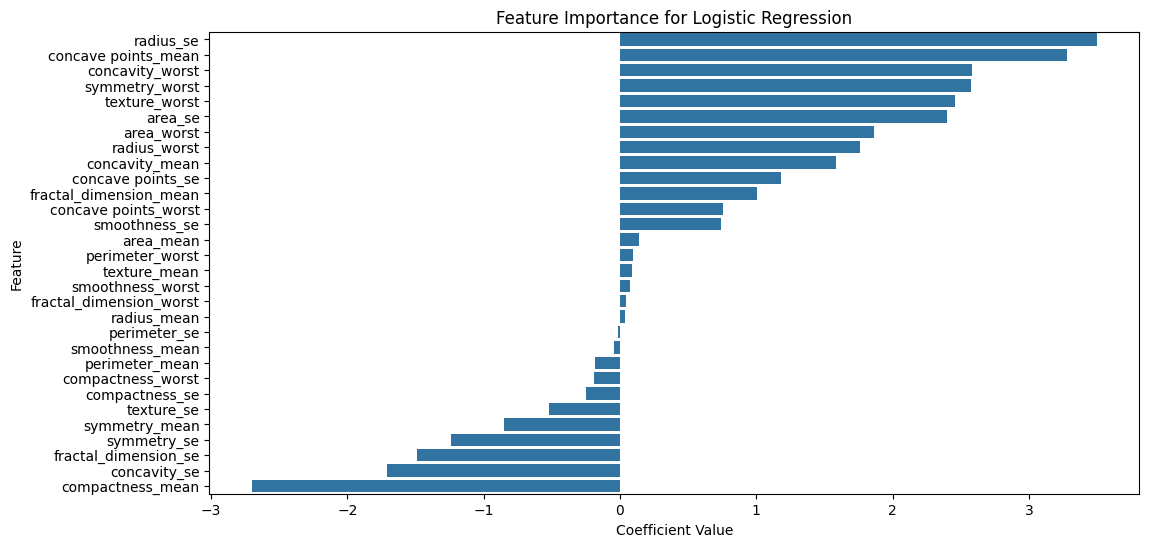

In [27]:
# Create visualization of feature importance for the best model (Logistic Regression)
feature_importance = best_logistic_model.named_steps['classifier'].coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


## HPT Conclusions:
- We were able to improve the Logistic Regression with the grisearch from 0.9534 to 0.9767.

# Project Conclusions:
- Logistic Regression achieved the best performance, particularly in recall (0.9767 after HPT), which was deemed most adequate for the project in hand, as we want to minimize false negatives (malignant tumors classified as benign). Meaning that the decision boundary is probably close to linear, with no complex non-linear patterns needed (EDA showed mostly linear relations)

- This suggests that the relationship between features and the target variable is largely linear.

- Although features such as perimeter_mean and perimeter_worst show strong separation between classes in univariate analysis, their importance in the Logistic Regression model is reduced. This is likely due to multicollinearity, as these features are highly correlated with other variables such as radius and area. As a result, the model distributes importance across correlated features rather than assigning high weight to a single variable.

- Features such as radius_se and concave points_mean indicate a strong influence on predictions. However, due to the presence of highly correlated variables, these features likely act as representatives of broader groups (e.g., tumor size and shape characteristics), rather than being uniquely important on their own.

- The model demonstrates strong potential for assisting in early detection of malignant tumors.

## Limitations:

- Dataset size is relatively small.
- Potential multicollinearity between features.

## Future Work:

- Validate on external datasets.